Sales Data:
    product_id product_name     category  units_sold  sale_date
0            1    Product 1         Home          25 2025-01-01
1            2    Product 2       Sports          15 2025-01-02
2            3    Product 3  Electronics          17 2025-01-03
3            4    Product 4         Home          19 2025-01-04
4            5    Product 5         Home          21 2025-01-05
5            6    Product 6       Sports          17 2025-01-06
6            7    Product 7  Electronics          19 2025-01-07
7            8    Product 8  Electronics          16 2025-01-08
8            9    Product 9         Home          21 2025-01-09
9           10   Product 10     Clothing          21 2025-01-10
10          11   Product 11         Home          17 2025-01-11
11          12   Product 12         Home          22 2025-01-12
12          13   Product 13         Home          14 2025-01-13
13          14   Product 14         Home          17 2025-01-14
14          15   Product 15 

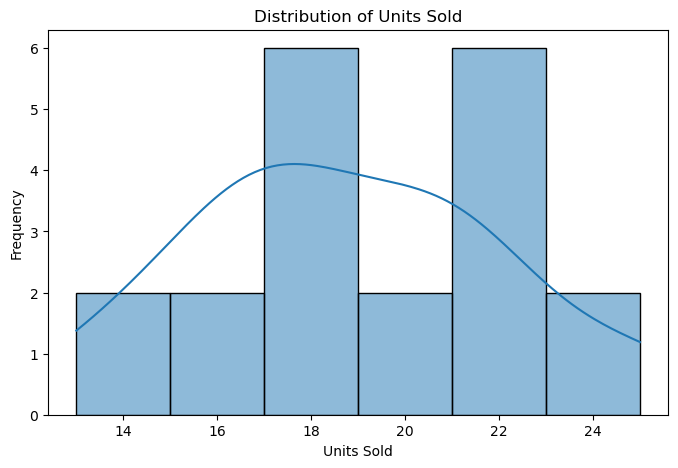

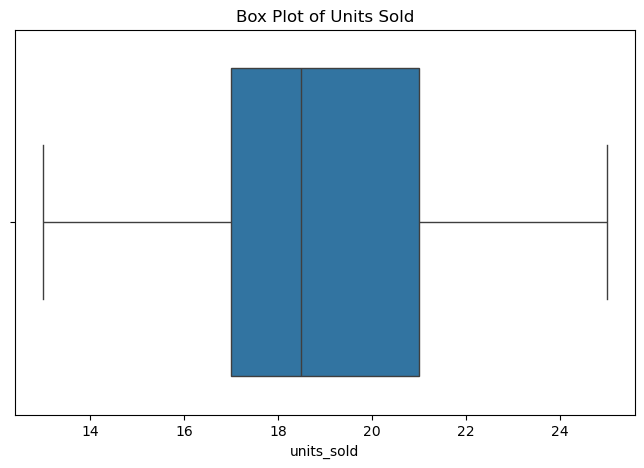

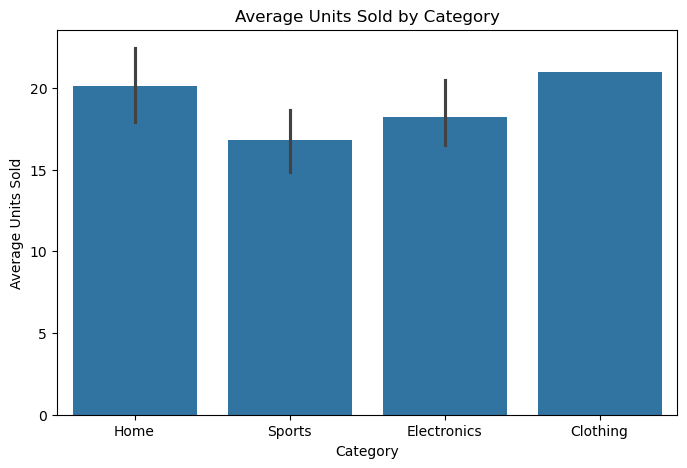

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# ==========================
# CREATE SAMPLE SALES DATA
# ==========================

np.random.seed(42)

data = {
    'product_id': range(1, 21),
    'product_name': [f'Product {i}' for i in range(1, 21)],
    'category': np.random.choice(
        ['Electronics', 'Clothing', 'Home', 'Sports'],
        size=20
    ),
    'units_sold': np.random.poisson(lam=20, size=20),
    'sale_date': pd.date_range(
        start='2025-01-01',
        periods=20,
        freq='D'
    )
}

sales_data = pd.DataFrame(data)

print("Sales Data:")
print(sales_data)

# ==========================
# DESCRIPTIVE STATISTICS
# ==========================

descriptive_stats = sales_data['units_sold'].describe()

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
print(descriptive_stats)

# Additional Statistics

mean_sales = sales_data['units_sold'].mean()
median_sales = sales_data['units_sold'].median()
mode_sales = sales_data['units_sold'].mode()[0]
variance_sales = sales_data['units_sold'].var()
std_deviation_sales = sales_data['units_sold'].std()
min_sales = sales_data['units_sold'].min()
max_sales = sales_data['units_sold'].max()
range_sales = max_sales - min_sales
skewness_sales = sales_data['units_sold'].skew()
kurtosis_sales = sales_data['units_sold'].kurt()

print("\nADDITIONAL STATISTICS")
print("-" * 50)
print(f"Mean Units Sold              : {mean_sales:.2f}")
print(f"Median Units Sold            : {median_sales}")
print(f"Mode Units Sold              : {mode_sales}")
print(f"Variance of Units Sold       : {variance_sales:.2f}")
print(f"Standard Deviation           : {std_deviation_sales:.2f}")
print(f"Minimum Units Sold           : {min_sales}")
print(f"Maximum Units Sold           : {max_sales}")
print(f"Range                        : {range_sales}")
print(f"Skewness                     : {skewness_sales:.2f}")
print(f"Kurtosis                     : {kurtosis_sales:.2f}")

# ==========================
# CATEGORY-WISE ANALYSIS
# ==========================

category_stats = (
    sales_data.groupby('category')['units_sold']
    .agg(['sum', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
)

category_stats.columns = [
    'Category',
    'Total Units Sold',
    'Average Units Sold',
    'Median Units Sold',
    'Std Dev of Units Sold',
    'Minimum Units Sold',
    'Maximum Units Sold'
]

print("\n" + "=" * 50)
print("CATEGORY-WISE STATISTICS")
print("=" * 50)
print(category_stats)

# ==========================
# VISUALIZATIONS
# ==========================

# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(sales_data['units_sold'], kde=True)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

# Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x=sales_data['units_sold'])
plt.title('Box Plot of Units Sold')
plt.show()

# Category-wise Average Sales
plt.figure(figsize=(8, 5))
sns.barplot(
    data=sales_data,
    x='category',
    y='units_sold',
    estimator=np.mean
)
plt.title('Average Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Average Units Sold')
plt.show()

In [4]:
# ==========================
# INFERENTIAL STATISTICS
# ==========================

confidence_level = 0.95

# Sample statistics
sample_mean = sales_data['units_sold'].mean()
sample_std = sales_data['units_sold'].std()
sample_size = len(sales_data['units_sold'])

# Standard Error
standard_error = sample_std / np.sqrt(sample_size)

# Degrees of Freedom
degrees_freedom = sample_size - 1

# t-score for 95% confidence interval
t_score = stats.t.ppf(
    (1 + confidence_level) / 2,
    degrees_freedom
)

# Margin of Error
margin_of_error = t_score * standard_error

# Confidence Interval
confidence_interval = (
    sample_mean - margin_of_error,
    sample_mean + margin_of_error
)

print("\n" + "=" * 50)
print("INFERENTIAL STATISTICS")
print("=" * 50)
print(f"Confidence Level : {confidence_level * 100}%")
print(f"Sample Mean      : {sample_mean:.2f}")
print(f"Standard Error   : {standard_error:.2f}")
print(f"t-Score          : {t_score:.4f}")
print(f"Margin of Error  : {margin_of_error:.2f}")
print(
    f"95% Confidence Interval: "
    f"({confidence_interval[0]:.2f}, "
    f"{confidence_interval[1]:.2f})"
)


INFERENTIAL STATISTICS
Confidence Level : 95.0%
Sample Mean      : 18.80
Standard Error   : 0.74
t-Score          : 2.0930
Margin of Error  : 1.55
95% Confidence Interval: (17.25, 20.35)


In [ ]:
# ==========================
# HYPOTHESIS TESTING (T-TEST)
# ==========================

# Null Hypothesis (H0):
# Mean units sold = 20

# Alternative Hypothesis (H1):
# Mean units sold ≠ 20

t_statistic, p_value = stats.ttest_1samp(
    sales_data['units_sold'],
    20
)

print("\n" + "=" * 50)
print("HYPOTHESIS TESTING (ONE-SAMPLE T-TEST)")
print("=" * 50)

print(f"T-Statistic : {t_statistic:.4f}")
print(f"P-Value     : {p_value:.4f}")

alpha = 0.05
# p_value is 0.05 because we are testing confidence for 95% if confidence test is for 99% then p_value will be 0.01
if p_value < alpha:
    print("\nResult:")
    print("Reject the Null Hypothesis (H0)")
    print("The mean units sold is significantly different from 20.")
else:
    print("\nResult:")
    print("Fail to Reject the Null Hypothesis (H0)")
    print("The mean units sold is NOT significantly different from 20.")


HYPOTHESIS TESTING (ONE-SAMPLE T-TEST)
T-Statistic : -1.6251
P-Value     : 0.1206

Result:
Fail to Reject the Null Hypothesis (H0)
The mean units sold is NOT significantly different from 20.
